# 🛰️ Example: Creating Time-Ordered Data (TOD)

This notebook demonstrates how to generate **Time-Ordered Data (TOD)** for a set of detectors,  
starting from a mock TIM data cube created with **SIDES**.

The workflow is as follows:

1. **Define a telescope scan path** on the sky.  
2. **Project the detector array** onto the sky, given the relative positions of the detectors.  
3. **Sample the simulated sky signal** along these paths to build the TOD.



In [1]:
from src.load_params import load_params, format_duration
from src.scan_fcts import *
from src.astrometry_fcts import *
from src.hdf5_fcts import *
from astropy.io import fits 
import os
from astropy.wcs import WCS
from gen_timestreams import gen_tod
import matplotlib.patches as mpatches
from matplotlib.pyplot import cm
import random

In [2]:
#Load the coordinates of the field using Astropy.
name='Goods-S Field'
c=SkyCoord.from_name(name)
ra = 0 
rafield= c.ra.value
dec = c.dec.value
#The contour of the field
contours = np.array([[-27.7, 53], [-27.96, 53.09], [-27.9, 53.26], [-27.65, 53.16], [-27.7, 53]])
x_cen, y_cen = np.mean(contours[:, 1]), np.mean(contours[:, 0])

#Simulation use to generate the sky amplitude
simu_sky_path = 'fits_and_hdf5/pySIDES_from_uchuu_TIM_tophat_tile0_1deg_1deg_res30arcsec_R250_full_de_Looze_smoothed_MJy_sr.fits'

#Output file
tod_file='fits_and_hdf5/'+f'TOD_example.hdf5'

#Define the observer position
lat = -77.83 #deg

#Define the angular resolution. 
#if not specified, load it from the mock cube.
res = None
if(res is None):
    hdr = fits.getheader(simu_sky_path)
    res = (hdr['CDELT1'] * u.Unit(hdr['CUNIT1'])).to(u.deg).value

#Angle of the rotation to apply to the detector array. 
theta = np.radians(0)

In [3]:
#We will generate a TOD of duration T_duration.
T_duration = 1+0/60+0/3600 #h, min, s
# Define the acquisition rate, or how many samples the detectors acquire per second during T_duration.
acquisition_frequency = 488  #Hz
# Computes the sampling/acquisition period. It makes the timestep non rational to avoid some stripes in the hitmap. 
dt = 1/acquisition_frequency/3600*np.pi/3.14 #dt in hours. 
#Sample Per Frame (spf), defined as the round number of sample per second. It will be used to load the data again in Namap. 
spf = np.round(acquisition_frequency).astype(int) 

#Generate the Local Sideral Time (LST) array
LST = np.arange(-T_duration/2,T_duration/2,dt) #hours
#Generate the timestamp array in seconds.
T = LST*3600 #s 

## 📡 Telescope Scan Path

    #Generate the pointing on the sky for the center of the arrays
    scan_path_sky, azel = genPointingPath(T, scan_path, LST, lat, dec, ra, azel=True) 
    #----------------------------------------

Next, we generate the **path of the telescope, such as we want it to scan the field**.  

The following functions use the parameters:

- **`az_size`** — width of the field to scan (in degrees).  
- **`alt_size`** — height of the field to scan (in degrees).  
- **`alt_step`** — step height to take to reach alt_size (in degrees).  
  - Notes that the number of steps is defined as alt_size/alt_step. 
  - Thus when alt_size = alt_step, the telescope do not step in elevation
- **`acc`** — acceleration used for telescope turnarounds at the field edges (in deg·s⁻²).  
- **`scan_v`** — constant angular speed of the telescope while crossing the field in azimuth (in deg·s⁻¹).  
- **`dt`** — sampling period of the telescope path (in seconds).  

**Returned values:**

- **`az, alt`** — timestreams of the telescope coordinates.  
- **`flag`** — scan phase indicator:  
  - `1` → constant-speed scanning across the field.  
  - `0` → deceleration/acceleration turnarounds.


1
2
1


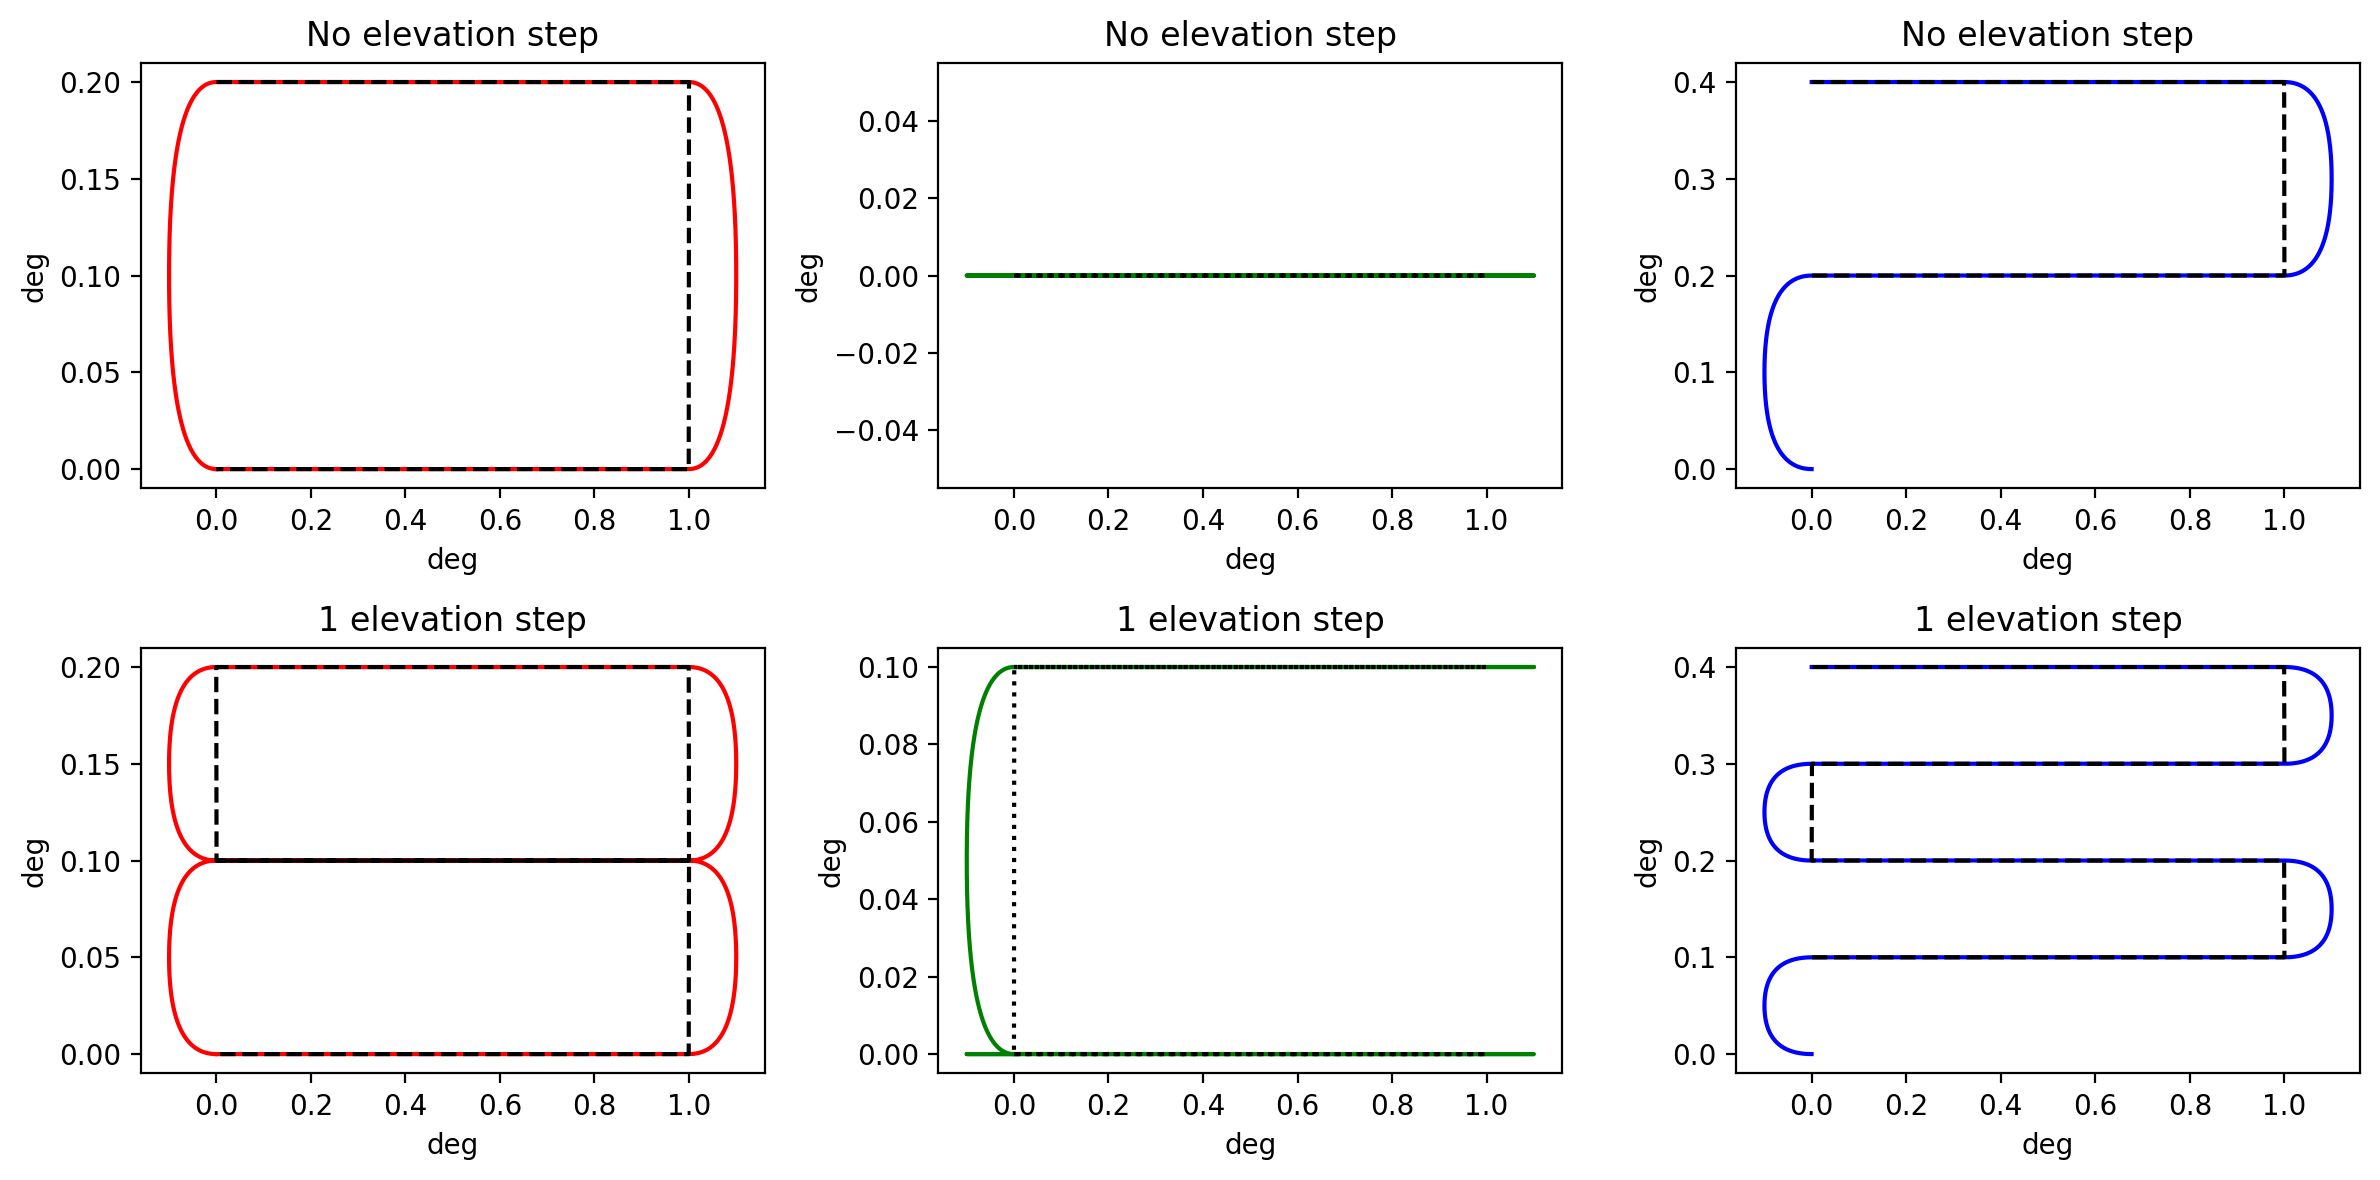

In [4]:
az_size = 1
alt_size = 0.2
alt_step = 0.1
acc = 0.05
scan_v = 0.1

fig, axs = plt.subplots(2,3,figsize=(12,6), dpi=200) 
for ia, alt_step in enumerate((0.2,0.1)):
    #The 'loop' pattern
    az, alt, flag = genLocalPath(az_size=az_size, alt_size=alt_size, alt_step=alt_step, acc=acc, scan_v=scan_v, dt=np.round(dt*3600,3))
    axs[ia,0].plot(az,alt,'r')
    axs[ia,0].plot(az[flag==1],alt[flag==1],'--k')
    #The 'raster' patternalt_step
    az, alt, flag = genLocalPath_cst_el_scan(az_size=az_size, alt_size=alt_size, alt_step=alt_step, acc=acc, scan_v=scan_v, dt=np.round(dt*3600,3))
    axs[ia,1].plot(az,alt,'g')
    axs[ia,1].plot(az[flag==1],alt[flag==1],':k')
    #The 'criss cross' pattern
    az, alt, flag = genLocalPath_cst_el_scan_crisscross(az_size=az_size, alt_size=alt_size, alt_step=alt_step, acc=acc, scan_v=scan_v, dt=np.round(dt*3600,3))
    axs[ia,2].plot(az,alt,'b')
    axs[ia,2].plot(az[flag==1],alt[flag==1],'--k')
    for i in range(3):
        axs[ia,i].set_ylabel('deg')
        axs[ia,i].set_xlabel('deg')
        axs[0,i].set_title(f'No elevation step')
        axs[1,i].set_title(f'1 elevation step')
fig.tight_layout()

#Let's keep the raster scan, without elevation steps. 
az, alt, flag = genLocalPath_cst_el_scan(az_size=az_size, alt_size=alt_size, alt_step=alt_size, acc=acc, scan_v=scan_v, dt=np.round(dt*3600,3))


In [5]:
#This pattern takes less time than T_duration. 
#Thus we generate the complete scan by repeating the pattern: 
scan_path, scan_flag = genScanPath(T, dt, alt, az, flag)

#Generate the pointing on the sky for the center of the arrays
scan_path_sky, azel = genPointingPath(T, scan_path, LST, lat, dec, azel=True) 

#Compute the number of time a sky pixel is hit by the telescope. 
hitmap, xedges, yedges = np.histogram2d(scan_path_sky[:,0], scan_path_sky[:,1], bins=int(2/res))

One pattern: 0.48 min, repeats: 125, leftover: 0.20 min


The path is 301.1 deg in length.


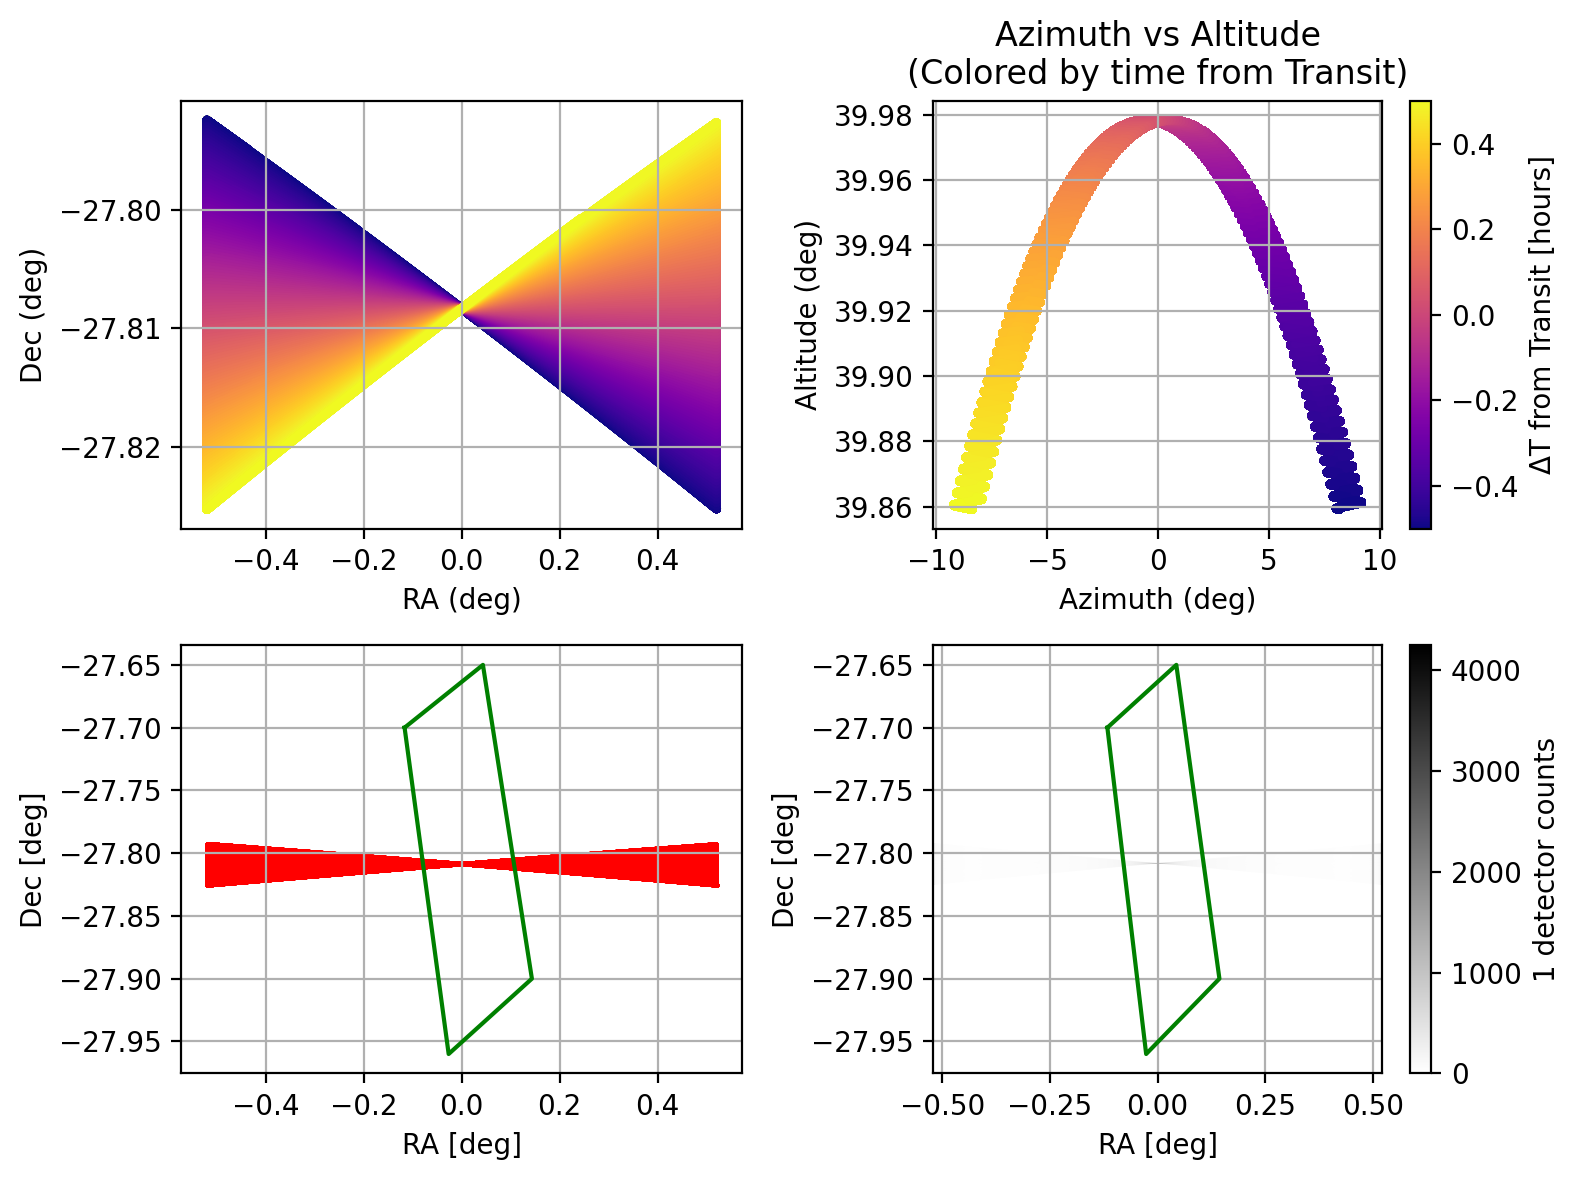

In [6]:
# === Plot Az vs Alt with delta_hours as color ===
fig, axS = plt.subplots(2,2,figsize=(8,6), dpi=200)
axs, axr, axc, ax = axS[0,0], axS[0,1], axS[1,0], axS[1,1]
axs.scatter(scan_path_sky[:,0],scan_path_sky[:,1], c=T/3600, cmap='plasma', s=5)
# Attach colorbar to the left subplot (axs[0])
axs.set_xlabel('RA (deg)')
axs.set_ylabel('Dec (deg)')
axs.grid(True)
az_unwrapped = (np.radians(azel[:,0]) + np.pi) % (2 * np.pi) - np.pi
sc = axr.scatter(np.degrees(az_unwrapped),azel[:,1],c=T/3600, cmap='plasma', s=5)

coords = SkyCoord(alt=np.degrees(az_unwrapped)*u.deg, az=azel[:,1]*u.deg, frame='altaz')
separations = coords[:-1].separation(coords[1:])
total_length = np.sum(separations)
print(f'The path is {total_length:.1f} in length.')

cbar = plt.colorbar(sc, ax=axr)
cbar.set_label('ΔT from Transit [hours]')
axr.set_xlabel('Azimuth (deg)')
axr.set_ylabel('Altitude (deg)')
axr.set_title('Azimuth vs Altitude\n(Colored by time from Transit)')
axr.grid()
#---
im = ax.imshow(hitmap.T, origin='lower', cmap='binary',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
cbar = fig.colorbar(im, ax=ax, label='1 detector counts')
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_aspect('auto')
if(contours is not None):
    ax.plot(contours[:, 1]-rafield, contours[:, 0], c='g' )
    axc.plot(contours[:, 1]-rafield, contours[:, 0], c='g' )
axc.scatter(scan_path_sky[:,0], scan_path_sky[:,1], s=0.1,c='r')
axc.set_xlabel('RA [deg]')
axc.set_ylabel('Dec [deg]')
ax.grid()
axc.grid()
#---
fig.tight_layout()

In [7]:
#We can stop here and save the TOD in .hdf5
#----------------------------------------
lat = np.ones(len(LST)) * lat
save_scan_path(tod_file, np.array((LST, lat)).T, spf,acquisition_frequency, ('lst', 'lat'))
save_scan_path(tod_file, azel, spf,acquisition_frequency,('AZ', 'EL'))
save_scan_path(tod_file, scan_path_sky, spf, acquisition_frequency,('RA', 'DEC'))
save_scan_path(tod_file, scan_path,     spf, acquisition_frequency,('RA_path', 'DEC_path'))
save_timestamps(tod_file, T, spf, acquisition_frequency,'time')
save_timestamps(tod_file, scan_flag, spf, acquisition_frequency,'turnaround_flags')
#-------------------------------------------

In [8]:
#Now we can define an array of detectors, composed of a short wavelenght (SW) and a long wavelenght array (LW).
nb_pixel_SW = 64
nb_pixel_LW = 51
#Angular Separation between detectors in elevation
separation_between_detectors_SW = 0.0145 #deg
separation_between_detectors_LW = 0.0182 #deg
#Angular Separation between detectors in cross-elevation
separation_between_array = 0.066 #deg

#Generate the offsets in (Elevation, cross-Elevation) of the detectors w.r.t the center of the two arrays, in degrees. 
pixel_offset_EL = []
pixel_offset_xEL = []

for nbpix, sep_detc, sep_arr in zip((nb_pixel_SW,nb_pixel_LW), 
                                   (separation_between_detectors_SW,separation_between_detectors_LW), 
                                   (-separation_between_array/2, separation_between_array/2)):
    pixel_EL, pixel_xEL = pixelOffset(nbpix, sep_detc, sep_arr)
    pixel_offset_EL = np.concatenate((pixel_offset_EL, pixel_EL))
    pixel_offset_xEL = np.concatenate((pixel_offset_xEL, pixel_xEL))

#Apply a rotation if any. 
pixel_offsets = pixels_rotations(pixel_offset_EL, pixel_offset_xEL, theta)

In [9]:
#Generate the pointing on the sky of each detector
pointing_paths = [genPointingPath(T, scan_path, LST, lat, dec, offsets) for offsets in pixel_offsets]

#Generate the hitmap, using all the detectors. 
xedges,yedges,hit_map = binMap(pointing_paths,res=res,dec=dec,ra=ra) 

/tmp/ipykernel_85434/1263453440.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axpix.scatter(pointing_paths[i][::n,0], pointing_paths[i][::n,1], s=0.1,c=c)


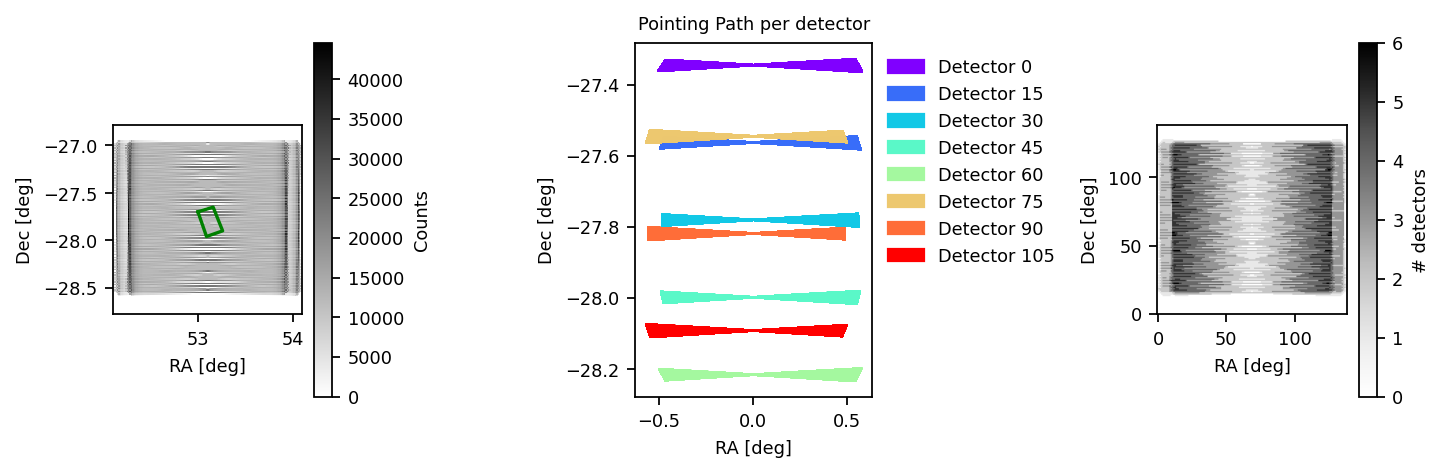

In [12]:
#Plot a scan route
BS = 8; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS)
fig, axs = plt.subplots(1,3,figsize=(9,3), dpi=160,)
#---
axp, axpix, axdet = axs[0], axs[1], axs[2]
img = axp.imshow((hit_map), extent=[x_cen-1, x_cen+1,y_cen-1, y_cen+1,], 
                interpolation='nearest', origin='lower', vmin=0, vmax=np.max(hit_map), cmap='binary' )
if(contours is not None): axp.plot(contours[:, 1], contours[:, 0], c= 'g')
fig.colorbar(img, ax=axp, label='Counts')
axp.set_xlabel('RA [deg]')
axp.set_ylabel('Dec [deg]')
#---
patchs = []
axpix.set_title('Pointing Path per detector')
idx = np.arange(len(pointing_paths))[::15]
n = 11
for i,c in zip(idx, cm.rainbow(np.linspace(0.,1,len(idx)))):
    axpix.scatter(pointing_paths[i][::n,0], pointing_paths[i][::n,1], s=0.1,c=c)
    patch = mpatches.Patch(color=c, label= 'Detector %d'%i); patchs.append(patch); 
#axpix.set_aspect(aspect=1)
axpix.legend(handles=patchs,frameon=False, bbox_to_anchor=(1,1))
axpix.set_xlabel('RA [deg]')
axpix.set_ylabel('Dec [deg]')

#----------------------------------------------------------------------
hit_maps = []
for idx in range(len(pointing_paths)):
    xedges,yedges,hitmap = binMap(pointing_paths[idx],res=res,dec=dec,ra=ra, shape= hit_map.shape)  
    hit_maps.append(hitmap)
hit_maps = np.asarray(hit_maps)
det_map = np.sum(np.asarray(hit_maps) > 0, axis=0)
img = axdet.imshow(det_map, origin='lower', cmap = 'Greys')
fig.colorbar(img, ax=axdet, label='# detectors')
#----------------------------------------------------------------------
axdet.set_xlabel('RA [deg]')
axdet.set_ylabel('Dec [deg]')
#-------------------------------

fig.tight_layout()

## 🌌 Creating Time-Ordered Data (TOD) from the Simulation

Now that we have the **detector pointing positions** on the sky as a function of time,  
we can generate the corresponding **sky amplitude TODs** using the extragalactic simulation.

Each detector samples the simulated sky signal along its own trajectory,  
resulting in a timestream of observed amplitudes — the **Time-Ordered Data (TOD)**.


In [11]:
#Load the sky simulation from which to generate the TODs from.
#Get the header
hdr  = fits.getheader(simu_sky_path)

#Get the pixel area in steradians
pix_size = ((hdr['CDELT1']*u.Unit(hdr['CUNIT1']))**2).to(u.sr).value

#Adapt the center coordinates of the simulation to the center of the field. 
hdr['CRVAL1'] = ra 
hdr['CRVAL2'] = dec
hdr['CRPIX1'] = hdr['NAXIS1']//2
hdr['CRPIX2'] = hdr['NAXIS2']//2

wcs = WCS(hdr, naxis=2) 
#Create the list of frequency channels of the simulated cube. 

if('R' in simu_sky_path): #logspaced frequencies
    freqs = ( np.exp( hdr['CRVAL3'] + hdr['CDELT3'] * np.arange(hdr['NAXIS3']) ) *u.Unit(hdr['CUNIT3']) ).to(u.GHz)
else: #linear spaced frequencies
    freqs =( np.arange(hdr['CRVAL3'], hdr['CRVAL3']+hdr['NAXIS3']*hdr['CDELT3'], hdr['CDELT3'])*u.Unit(hdr['CUNIT3']) ).to(u.GHz)

#Create the binning of the map in pixel coordinates. 
xbins = np.arange(-0.5, hdr['NAXIS1']+0.5, 1)
ybins = np.arange(-0.5, hdr['NAXIS2']+0.5, 1)

#load the angular spectral cube. 
cube = fits.getdata(simu_sky_path)
#Remove the mean in each map, to wich we are not sensitive. 
cubemean = np.mean(cube, axis=(1,2)) 
cube -= cubemean[:, None, None]
cube *= 1e6*pix_size #conversion MJy/sr to Jy/beam

In [12]:
#Groupe the detectors per array. 
#The Long Wavelenght array is on the right.
LW = pixel_offsets[pixel_offsets[:,0] > 0]
#The Short Wavelenght array is on the left.
SW = pixel_offsets[pixel_offsets[:,0] < 0]
pointing_paths = np.array(pointing_paths)
pointing_paths_LW = pointing_paths[pixel_offsets[:, 0] > 0]
pointing_paths_SW = pointing_paths[pixel_offsets[:, 0] < 0]

#The simulated intensity cube has ~140 frequency channels. 
#Here, we generate the data for only 3 frequency channels for each of the LW and the SW array as an example. 
nb_channels_per_array = 3

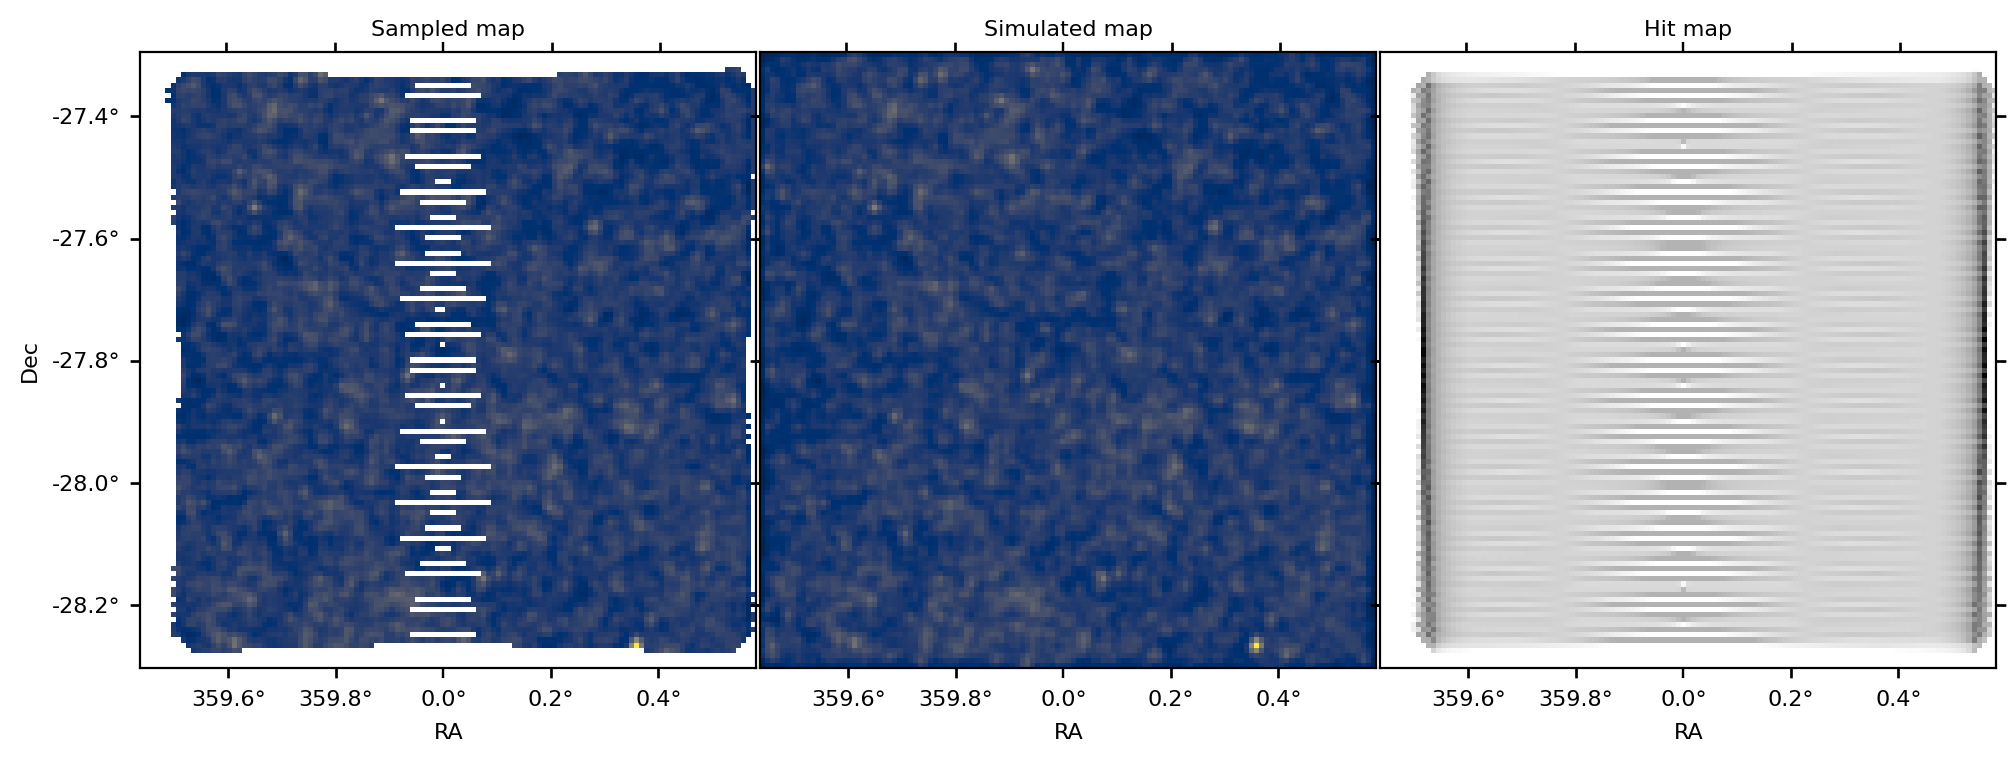

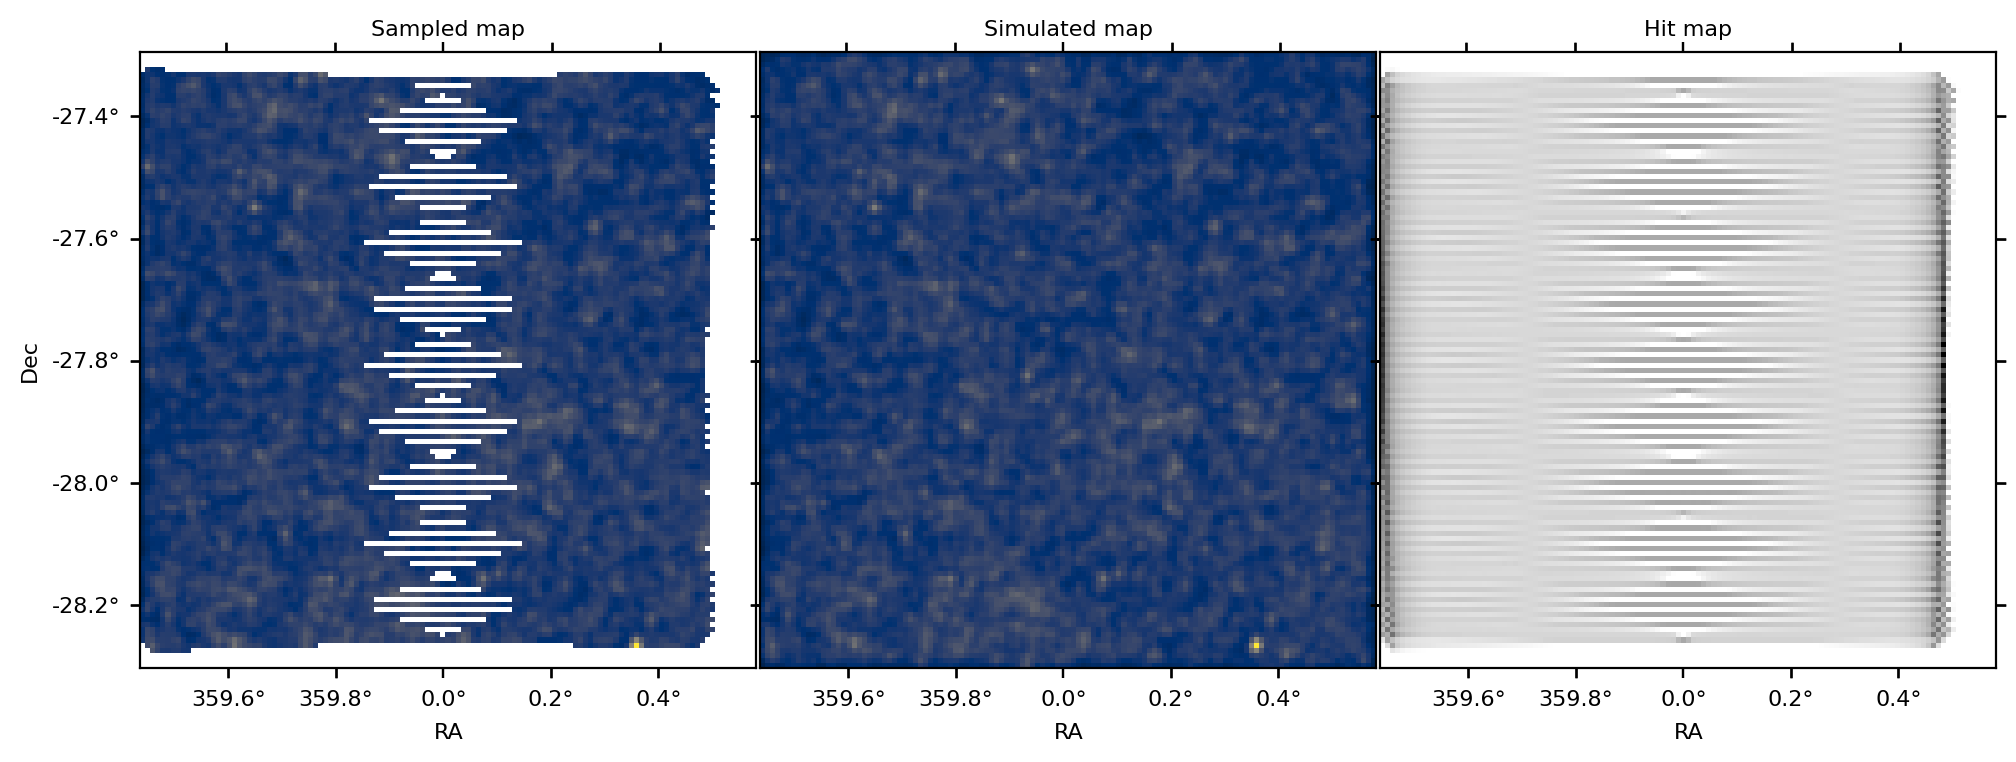

In [13]:
#For each array, the frequencies there are sensitive to, and the pointing paths of their detectors
for array_name, array, freqs_array, pointing_paths_to_save in zip(('SW', 'LW'), 
                                          (SW, LW),
                                          (freqs[:nb_channels_per_array], freqs[ nb_channels_per_array:nb_channels_per_array*2 ]),
                                          (pointing_paths_SW,pointing_paths_LW)):

    #For each frequency channel in the channels
    for fi, f in enumerate(freqs_array):

        #Select the electromagnetic frequency channel out of which the TODs will be sampled. 
        F = fi
        if(array_name=='LW'): F += nb_channels_per_array
        Map = cube[F,:,:]
        #----------------------------------------

        #----------------------------------------
        #Sample the sky amplitude from the map
        hist, norm, samples, positions_x, positions_y = gen_tod(wcs, Map, hdr, ybins, xbins, pointing_paths_to_save)
        #----------------------------------------
        # Create names for the detectors. 
        names = [f"{array_name}_{F}_{random.randint(0, 9999):04d}" for _ in range(len(pointing_paths_to_save))]

        #Save the TODs under the name of there detector, in an .hdf5 file that works like a dictionnary.
        #The .tsv file contains the names, angular offsets, and the electromagnetic frequency of each detectors. 
        save_tod_in_hdf5(tod_file, names, samples, array[:,0], array[:,1], 'example.tsv', freqs[F].value, spf, acquisition_frequency)

        #-----------------------------------------------------------------
        if(fi ==0 or False):
                
            fig, axs = plt.subplots(1,3, figsize=(12,4), dpi = 200,subplot_kw={'projection': wcs}, sharex=True, sharey=True )
            axs[0].set_title('Sampled map')
            axs[1].set_title('Simulated map')
            axs[2].set_title('Hit map')
            imgdec = axs[0].imshow(hist, interpolation='nearest', origin='lower', vmin=Map.min(), vmax=Map.max(), cmap='cividis' )
            img = axs[1].imshow(Map, interpolation='nearest', origin='lower', vmin=Map.min(), vmax=Map.max(), cmap='cividis' )
            count = axs[2].imshow(norm, interpolation='nearest', origin='lower', cmap='binary' )
            for ax in (axs[0], axs[1], axs[2]):
                lon = ax.coords[0]
                LAT = ax.coords[1]
                LAT.set_major_formatter('d.d')
                lon.set_major_formatter('d.d')
                lon.set_axislabel('RA')
                LAT.set_axislabel('Dec')
                if(ax is not axs[0]): ax.tick_params(axis='y', labelleft=False)
            plt.subplots_adjust(wspace=0, hspace=0)


# Pipeline Overview

This notebook corresponds to a series of scripts.  
All arguments are stored in a **`.par` file**.  
The same `.par` file should be used consistently across the different scripts.

---

1. Generate the path of a single detector

    The script `hitmap_1detector.py` generates the path on the sky for **one detector** and saves it in an `.hdf5` file.

    --> python hitmap_1detector.py PAR_files/params_strategy.par

2. Create detector arrays description

    The script `gen_detectors_arrays.py` creates a `.tsv` file containing the information on the detectors of the arrays, as defined by the `.par` file.

    --> python gen_detectors_arrays.py PAR_files/params_strategy.par

3. Generate sky paths for all detectors

    The script hitmap_arrays.py uses:

        the `.hdf5` file created by hitmap_1detector.py

        the `.tsv` file created by gen_detectors_arrays.py

    It then creates the path on the sky for all detectors and appends the result to the existing .hdf5 file.

    --> python hitmap_arrays.py PAR_files/params_strategy.par

4. Generate timestreams

    The script gen_timestreams.py uses the sky paths from the .hdf5 file to generate sky amplitude TODs for each detector, based on a simulated intensity cube.

        The TODs are saved in the .hdf5.

        The .tsv file is updated with the electromagnetic frequency channel (from the simulation) of each detector.

    --> python gen_timestreams.py PAR_files/params_strategy.